# 18 — RIPA2 vs Butterworth LF/HF: What Each Metric Sees

**RIPA2** (Jayawardena, Jayawardana & Gwizdka 2025): Savitzky-Golay derivative filters,
pointwise metric `(SG_LF · P)² − (SG_VLF · P)²`. Captures instantaneous rate-of-change
in pupil dynamics — sensitive to cognitive *transitions*.

**Butterworth LF/HF** (Duchowski 2026): IIR frequency-band power ratio (variance in
0–1.6 Hz vs 1.6–4 Hz). Captures sustained oscillatory state — sensitive to tonic
cognitive *load*.

**Key finding from batch comparison:** Both detect the positional gradient (LF/HF ρ=−0.926,
RIPA2 ρ=−0.809, both p<0.001), but they are uncorrelated at the observation level
(r=−0.023, n=6874). They measure different aspects of the same pupil signal.

**Task model prediction:**
- RIPA2 should spike at **phase transitions** (survey→evaluate, pre-click, regression onset)
- LF/HF should track **sustained phase load** (high during evaluation, low during scanning)
- **Divergence points** — high RIPA2 + low LF/HF = quick decision; low RIPA2 + high LF/HF = sustained deliberation

In [1]:
from data_loader import *
import json
import numpy as np
from collections import defaultdict
from scipy.stats import spearmanr, mannwhitneyu, pearsonr
import matplotlib.pyplot as plt

setup_plotting()

with open(DATA_DIR / 'butterworth-lfhf-by-position.json') as f:
    bw_data = json.load(f)

with open(DATA_DIR / 'ripa2-by-position.json') as f:
    ripa2_data = json.load(f)

print(f'{len(bw_data)} trials with Butterworth LF/HF')
print(f'{len(ripa2_data)} trials with RIPA2')

2719 trials with Butterworth LF/HF
2719 trials with RIPA2


## Observation-level correlation

6874 paired observations across 2719 trials
Pearson r = -0.023, p = 5.71e-02
Spearman ρ = 0.001, p = 9.56e-01


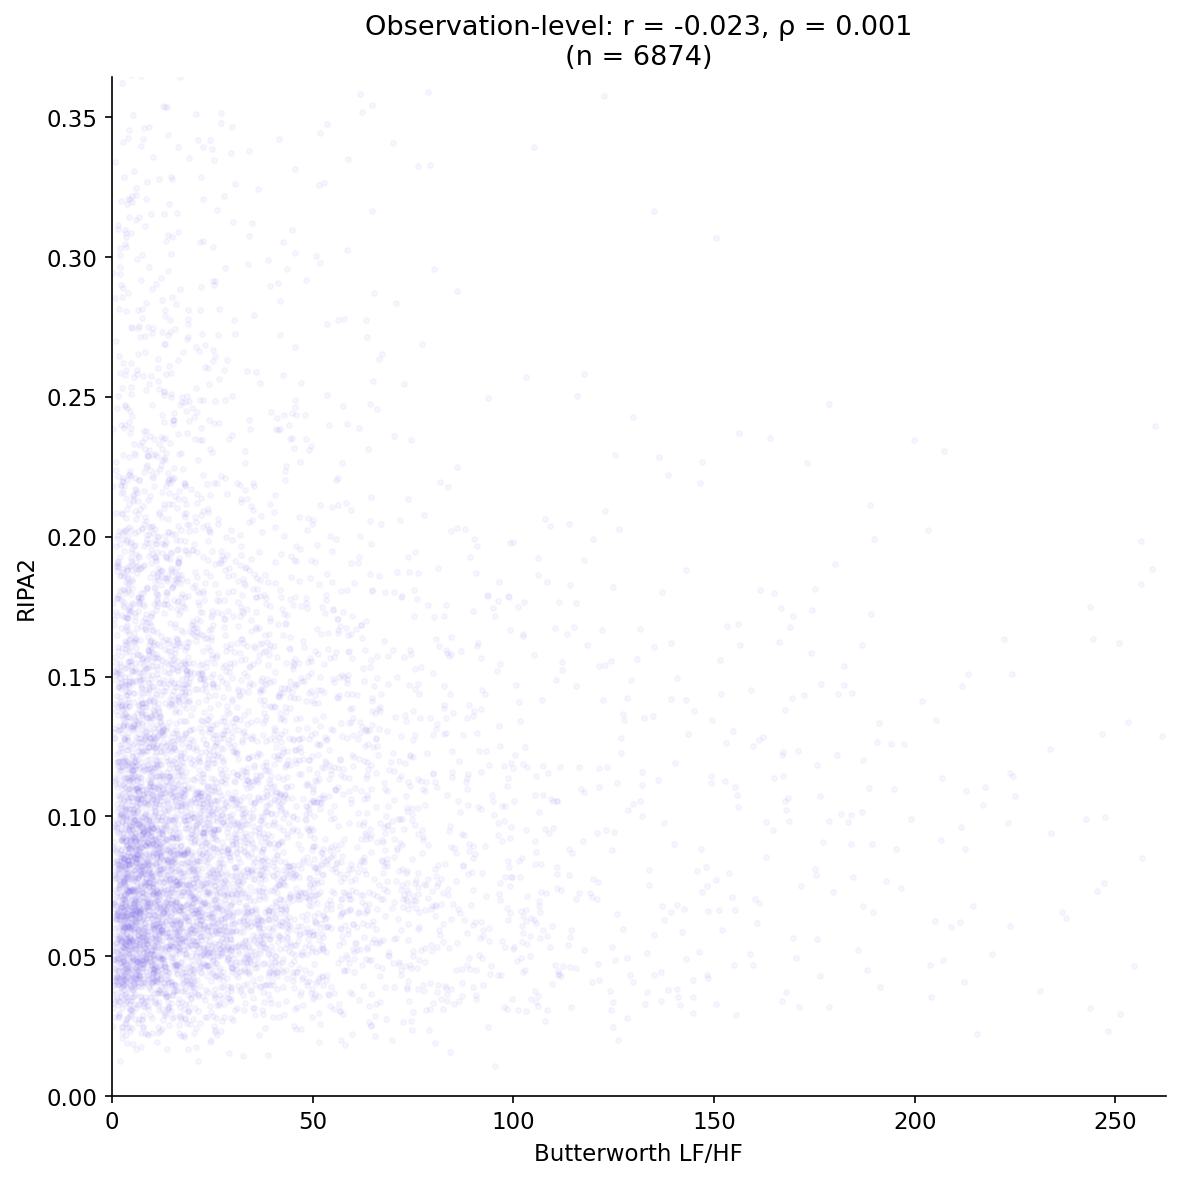

In [2]:
# Collect paired observations: same trial, same position
paired = []
common_trials = set(bw_data.keys()) & set(ripa2_data.keys())

for tid in common_trials:
    b_by_pos = {p['pos']: p['lfhf'] for p in bw_data[tid]['positions'] if p['lfhf'] is not None}
    r_by_pos = {p['pos']: p['ripa2'] for p in ripa2_data[tid]['positions'] if p['ripa2'] is not None}
    for pos in set(b_by_pos) & set(r_by_pos):
        paired.append((tid, pos, b_by_pos[pos], r_by_pos[pos]))

print(f'{len(paired)} paired observations across {len(common_trials)} trials')

tids, positions, lfhf_vals, ripa2_vals = zip(*paired)
lfhf_arr = np.array(lfhf_vals)
ripa2_arr = np.array(ripa2_vals)

r, p = pearsonr(lfhf_arr, ripa2_arr)
rho, rho_p = spearmanr(lfhf_arr, ripa2_arr)
print(f'Pearson r = {r:.3f}, p = {p:.2e}')
print(f'Spearman ρ = {rho:.3f}, p = {rho_p:.2e}')

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(lfhf_arr, ripa2_arr, alpha=0.05, s=6, color='#7b68ee')
ax.set_xlabel('Butterworth LF/HF')
ax.set_ylabel('RIPA2')
ax.set_title(f'Observation-level: r = {r:.3f}, ρ = {rho:.3f}\n(n = {len(paired)})')
ax.set_xlim(0, np.percentile(lfhf_arr, 99))
ax.set_ylim(0, np.percentile(ripa2_arr, 99))
plt.tight_layout()
plt.show()

## Positional gradient comparison

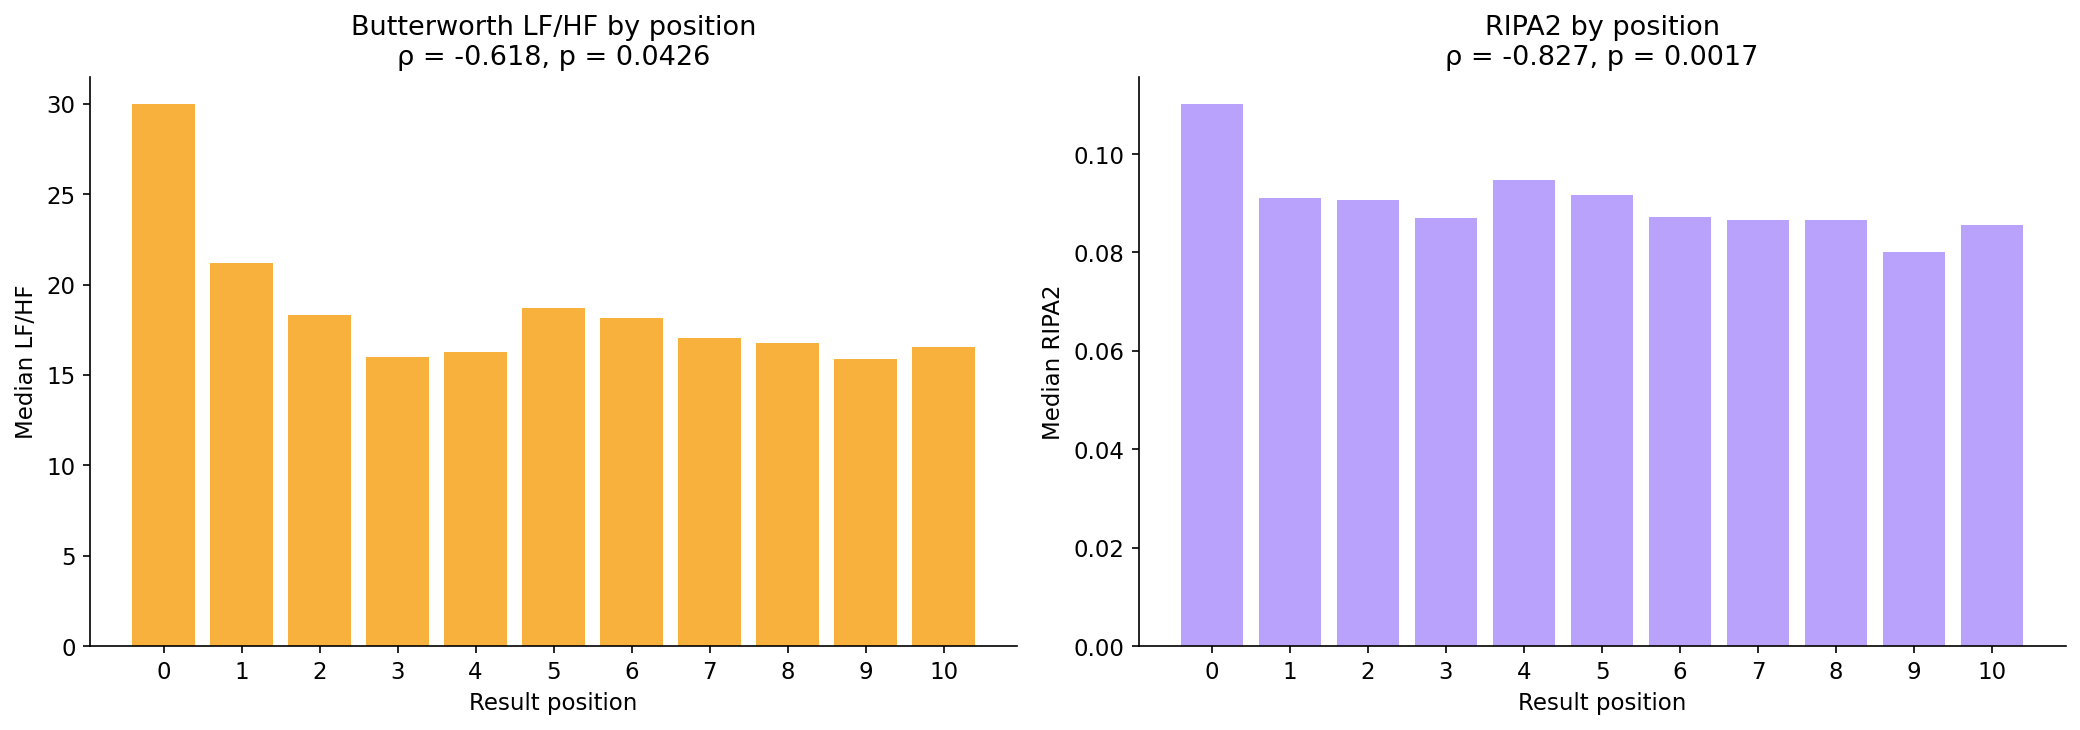


Positional gradient:
  LF/HF:  ρ = -0.618, p = 4.26e-02
  RIPA2:  ρ = -0.827, p = 1.68e-03


In [3]:
# Aggregate by position
lfhf_by_pos = defaultdict(list)
ripa2_by_pos = defaultdict(list)

for tid in common_trials:
    for p in bw_data[tid]['positions']:
        if p['lfhf'] is not None and 0 <= p['pos'] <= 10:
            lfhf_by_pos[p['pos']].append(p['lfhf'])
    for p in ripa2_data[tid]['positions']:
        if p['ripa2'] is not None and 0 <= p['pos'] <= 10:
            ripa2_by_pos[p['pos']].append(p['ripa2'])

pos_range = sorted(set(lfhf_by_pos.keys()) & set(ripa2_by_pos.keys()))

lfhf_medians = [np.median(lfhf_by_pos[p]) for p in pos_range]
ripa2_medians = [np.median(ripa2_by_pos[p]) for p in pos_range]

rho_l, p_l = spearmanr(pos_range, lfhf_medians)
rho_r, p_r = spearmanr(pos_range, ripa2_medians)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(pos_range, lfhf_medians, color='#f59e0b', alpha=0.8, edgecolor='none')
ax1.set_xlabel('Result position')
ax1.set_ylabel('Median LF/HF')
ax1.set_title(f'Butterworth LF/HF by position\nρ = {rho_l:.3f}, p = {p_l:.4f}')
ax1.set_xticks(pos_range)

ax2.bar(pos_range, ripa2_medians, color='#a78bfa', alpha=0.8, edgecolor='none')
ax2.set_xlabel('Result position')
ax2.set_ylabel('Median RIPA2')
ax2.set_title(f'RIPA2 by position\nρ = {rho_r:.3f}, p = {p_r:.4f}')
ax2.set_xticks(pos_range)

plt.tight_layout()
plt.show()

print(f'\nPositional gradient:')
print(f'  LF/HF:  ρ = {rho_l:+.3f}, p = {p_l:.2e}')
print(f'  RIPA2:  ρ = {rho_r:+.3f}, p = {p_r:.2e}')

## Divergence analysis: where the metrics disagree

Classify each observation into four quadrants based on median splits:
- **High LF/HF + High RIPA2**: sustained load AND sharp transition — effortful decision
- **High LF/HF + Low RIPA2**: sustained load, smooth dynamics — deliberation without resolution
- **Low LF/HF + High RIPA2**: low sustained load, sharp transition — quick decision
- **Low LF/HF + Low RIPA2**: low load, smooth — routine scanning

In [4]:
lfhf_med = np.median(lfhf_arr)
ripa2_med = np.median(ripa2_arr)

quadrants = {
    'Effortful decision\n(high LF/HF + high RIPA2)': (lfhf_arr >= lfhf_med) & (ripa2_arr >= ripa2_med),
    'Deliberation\n(high LF/HF + low RIPA2)': (lfhf_arr >= lfhf_med) & (ripa2_arr < ripa2_med),
    'Quick decision\n(low LF/HF + high RIPA2)': (lfhf_arr < lfhf_med) & (ripa2_arr >= ripa2_med),
    'Routine scanning\n(low LF/HF + low RIPA2)': (lfhf_arr < lfhf_med) & (ripa2_arr < ripa2_med),
}

print('Quadrant distribution:')
for label, mask in quadrants.items():
    pct = 100 * mask.sum() / len(mask)
    print(f'  {label.replace(chr(10), " "):50s}  {mask.sum():5d}  ({pct:.1f}%)')

# If uncorrelated, expect ~25% per quadrant. Deviations reveal structure.
print(f'\nExpected if independent: 25% each')
print(f'Chi-squared test of independence:')
from scipy.stats import chi2_contingency
table = np.array([[q.sum() for q in quadrants.values()]]).reshape(2, 2)
chi2, chi_p, dof, _ = chi2_contingency(table)
print(f'  χ² = {chi2:.1f}, p = {chi_p:.2e}')

Quadrant distribution:
  Effortful decision (high LF/HF + high RIPA2)         1732  (25.2%)
  Deliberation (high LF/HF + low RIPA2)                1705  (24.8%)
  Quick decision (low LF/HF + high RIPA2)              1705  (24.8%)
  Routine scanning (low LF/HF + low RIPA2)             1732  (25.2%)

Expected if independent: 25% each
Chi-squared test of independence:
  χ² = 0.4, p = 5.31e-01


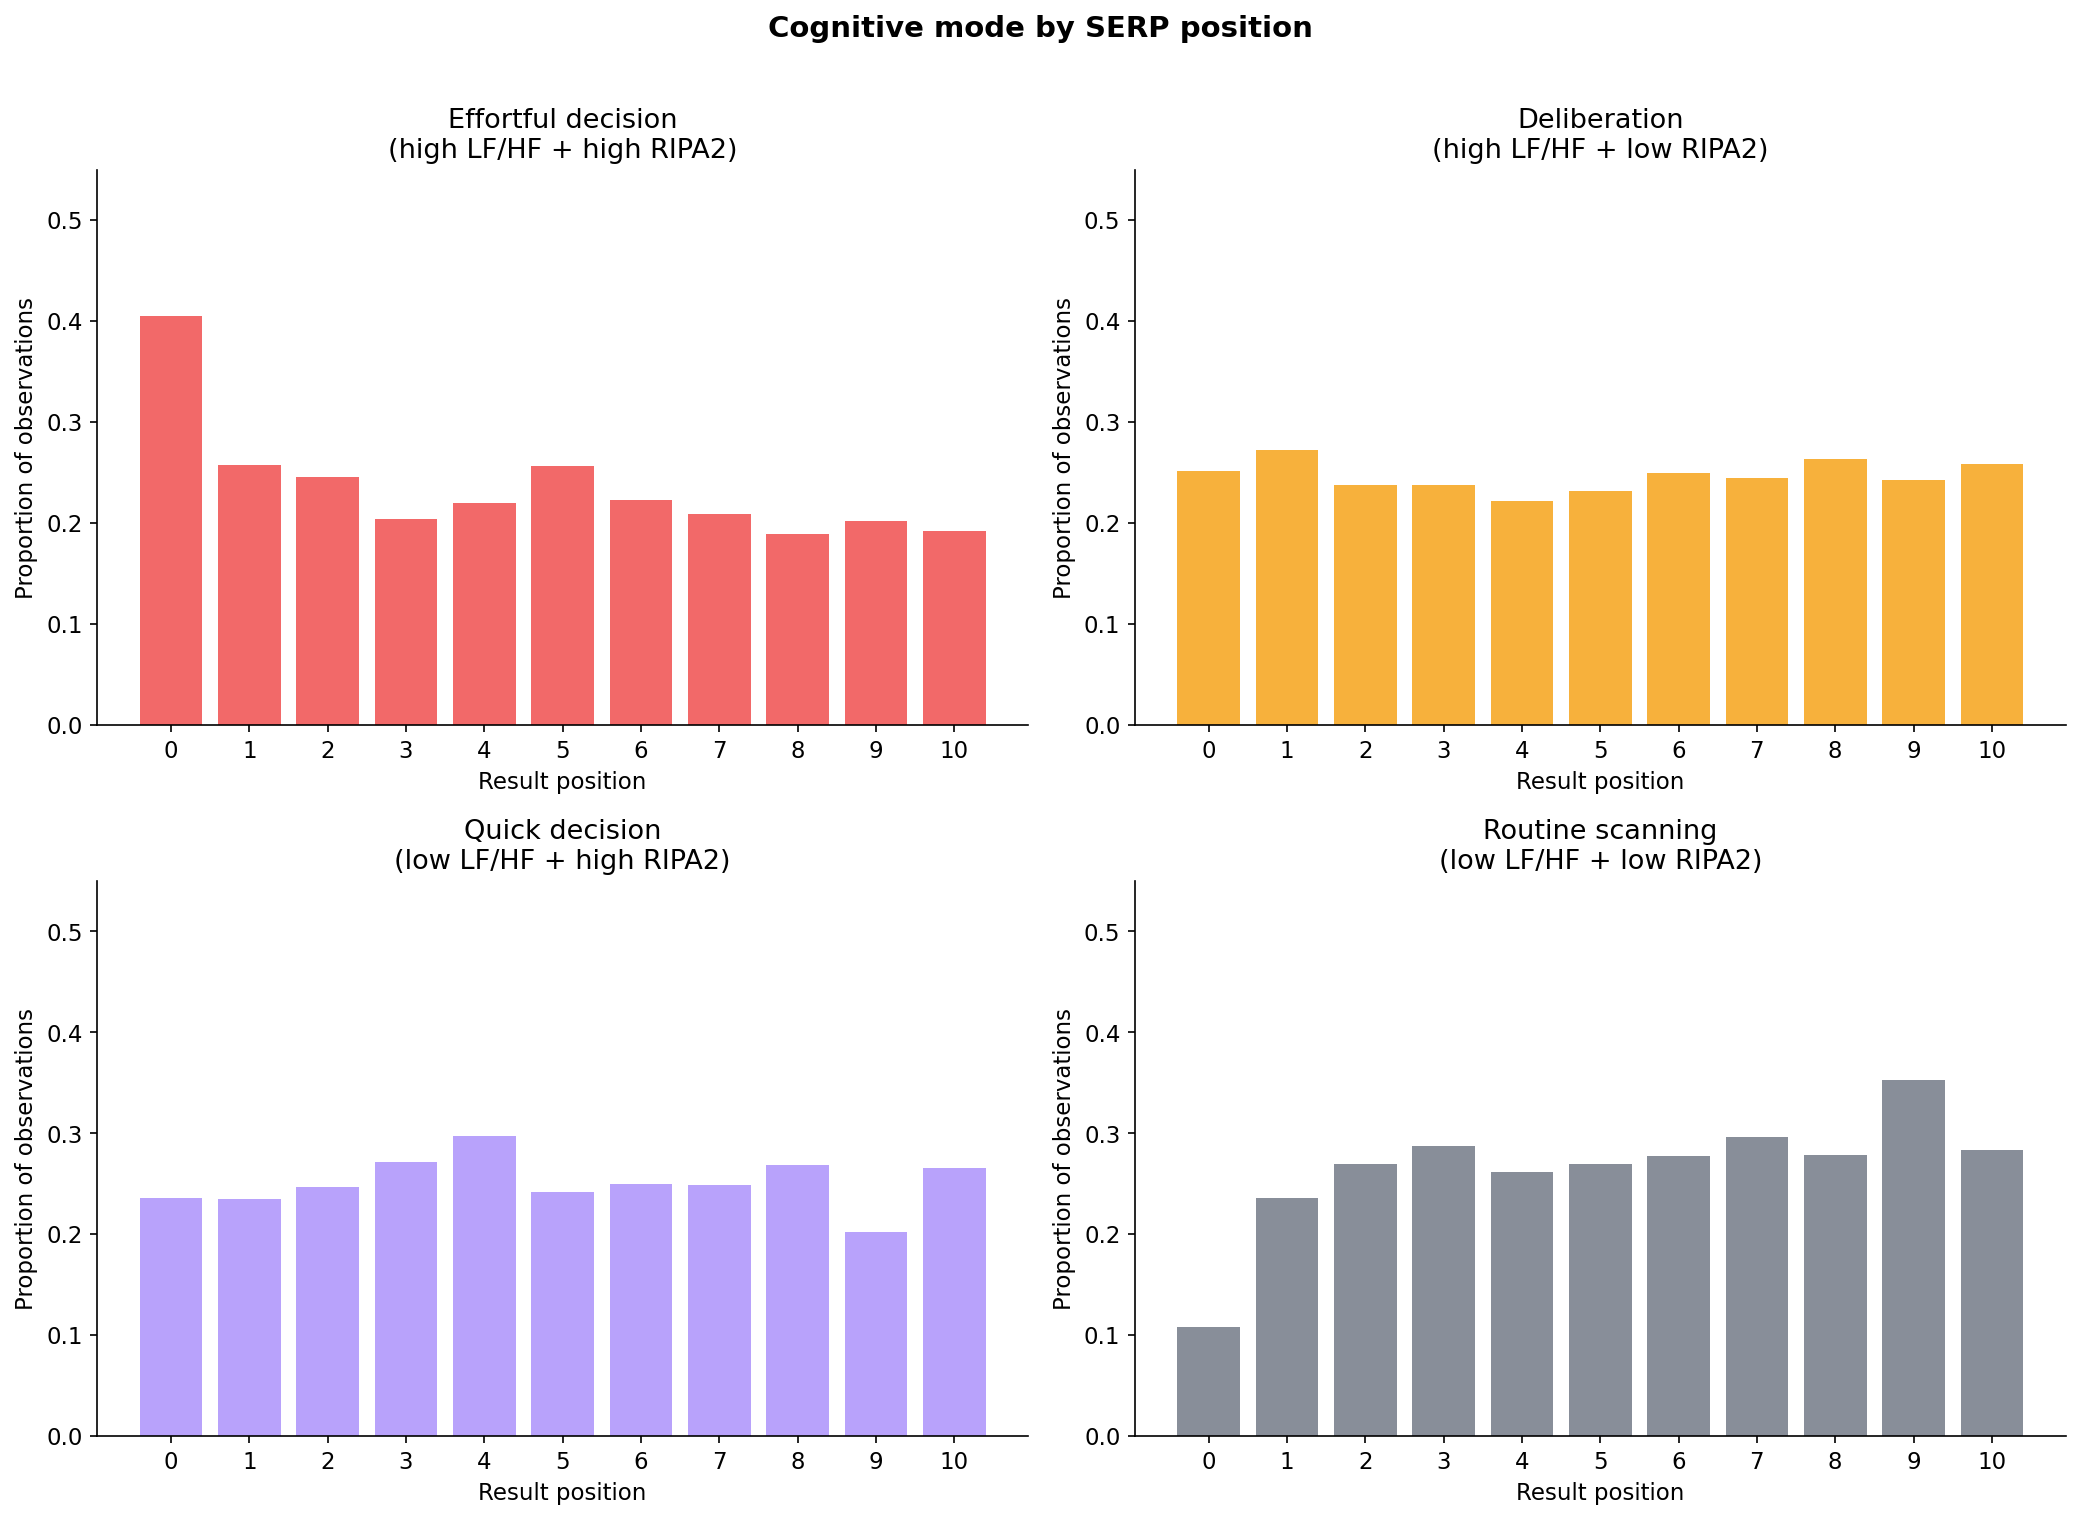

In [5]:
# Quadrant by position: how does each cognitive mode distribute across the SERP?
pos_arr = np.array([p[1] for p in paired])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
quad_colors = ['#ef4444', '#f59e0b', '#a78bfa', '#6b7280']
quad_labels = list(quadrants.keys())

for idx, (label, mask) in enumerate(quadrants.items()):
    ax = axes[idx // 2][idx % 2]
    q_positions = pos_arr[mask]
    valid_pos = q_positions[q_positions <= 10]
    if len(valid_pos) == 0:
        continue
    counts = np.bincount(valid_pos, minlength=11)
    # Normalize by total observations at each position
    total_at_pos = np.bincount(pos_arr[pos_arr <= 10], minlength=11)
    rates = np.where(total_at_pos > 0, counts / total_at_pos, 0)
    ax.bar(range(11), rates, color=quad_colors[idx], alpha=0.8, edgecolor='none')
    ax.set_xlabel('Result position')
    ax.set_ylabel('Proportion of observations')
    ax.set_title(label)
    ax.set_xticks(range(11))
    ax.set_ylim(0, 0.55)

plt.suptitle('Cognitive mode by SERP position', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Click position: does the clicked result have a distinctive signature?

In [6]:
# For each trial, classify clicked vs non-clicked positions into quadrants
click_quads = defaultdict(int)
nonclick_quads = defaultdict(int)

for i, (tid, pos, lf, ri) in enumerate(paired):
    click_pos = bw_data[tid].get('click_pos')
    is_clicked = (pos == click_pos)
    
    if lf >= lfhf_med and ri >= ripa2_med:
        q = 'effortful'
    elif lf >= lfhf_med and ri < ripa2_med:
        q = 'deliberation'
    elif lf < lfhf_med and ri >= ripa2_med:
        q = 'quick'
    else:
        q = 'routine'
    
    if is_clicked:
        click_quads[q] += 1
    else:
        nonclick_quads[q] += 1

print('Quadrant distribution for CLICKED vs NON-CLICKED results:')
print(f'{"Quadrant":>15s}  {"Clicked":>8s}  {"Non-click":>10s}  {"Click rate":>10s}')
print('-' * 50)
for q in ['effortful', 'deliberation', 'quick', 'routine']:
    c = click_quads[q]
    nc = nonclick_quads[q]
    rate = c / (c + nc) if (c + nc) > 0 else 0
    print(f'{q:>15s}  {c:>8d}  {nc:>10d}  {rate:>10.1%}')

Quadrant distribution for CLICKED vs NON-CLICKED results:
       Quadrant   Clicked   Non-click  Click rate
--------------------------------------------------
      effortful       339        1393       19.6%
   deliberation       310        1395       18.2%
          quick       286        1419       16.8%
        routine       259        1473       15.0%


## Survey vs Evaluate phase comparison

From notebook 06/13: survey phase ends at ~fixation 3, evaluate begins after.
Does RIPA2 spike at the transition while LF/HF shows a sustained shift?

In [7]:
# Load per-fixation data for demo trials
with open(DATA_DIR / 'fixation-lfhf-demo.json') as f:
    fix_lfhf = json.load(f)

with open(DATA_DIR / 'fixation-ripa2-demo.json') as f:
    fix_ripa2 = json.load(f)

# Pick trials with enough fixations and valid data for both metrics
good_trials = []
for tid in fix_lfhf:
    if tid not in fix_ripa2:
        continue
    n_lfhf = sum(1 for v in fix_lfhf[tid] if v is not None)
    n_ripa2 = sum(1 for v in fix_ripa2[tid] if v is not None)
    n_fix = len(fix_lfhf[tid])
    if n_ripa2 > 20 and n_lfhf > 5:
        good_trials.append((tid, n_fix, n_lfhf, n_ripa2))

good_trials.sort(key=lambda x: -x[1])  # longest first
print(f'{len(good_trials)} trials with both metrics:')
for tid, nf, nl, nr in good_trials:
    print(f'  {tid}: {nf} fixations, {nl} LF/HF, {nr} RIPA2')

9 trials with both metrics:
  p045-b2-t6: 312 fixations, 306 LF/HF, 312 RIPA2
  p037-b2-t5: 276 fixations, 272 LF/HF, 275 RIPA2
  p020-b6-t10: 230 fixations, 224 LF/HF, 230 RIPA2
  p047-b2-t6: 198 fixations, 192 LF/HF, 198 RIPA2
  p011-b3-t2: 91 fixations, 84 LF/HF, 86 RIPA2
  p047-b1-t9: 65 fixations, 61 LF/HF, 65 RIPA2
  p035-b4-t2: 61 fixations, 56 LF/HF, 61 RIPA2
  p016-b3-t1: 60 fixations, 56 LF/HF, 60 RIPA2
  p029-b2-t10: 22 fixations, 17 LF/HF, 22 RIPA2


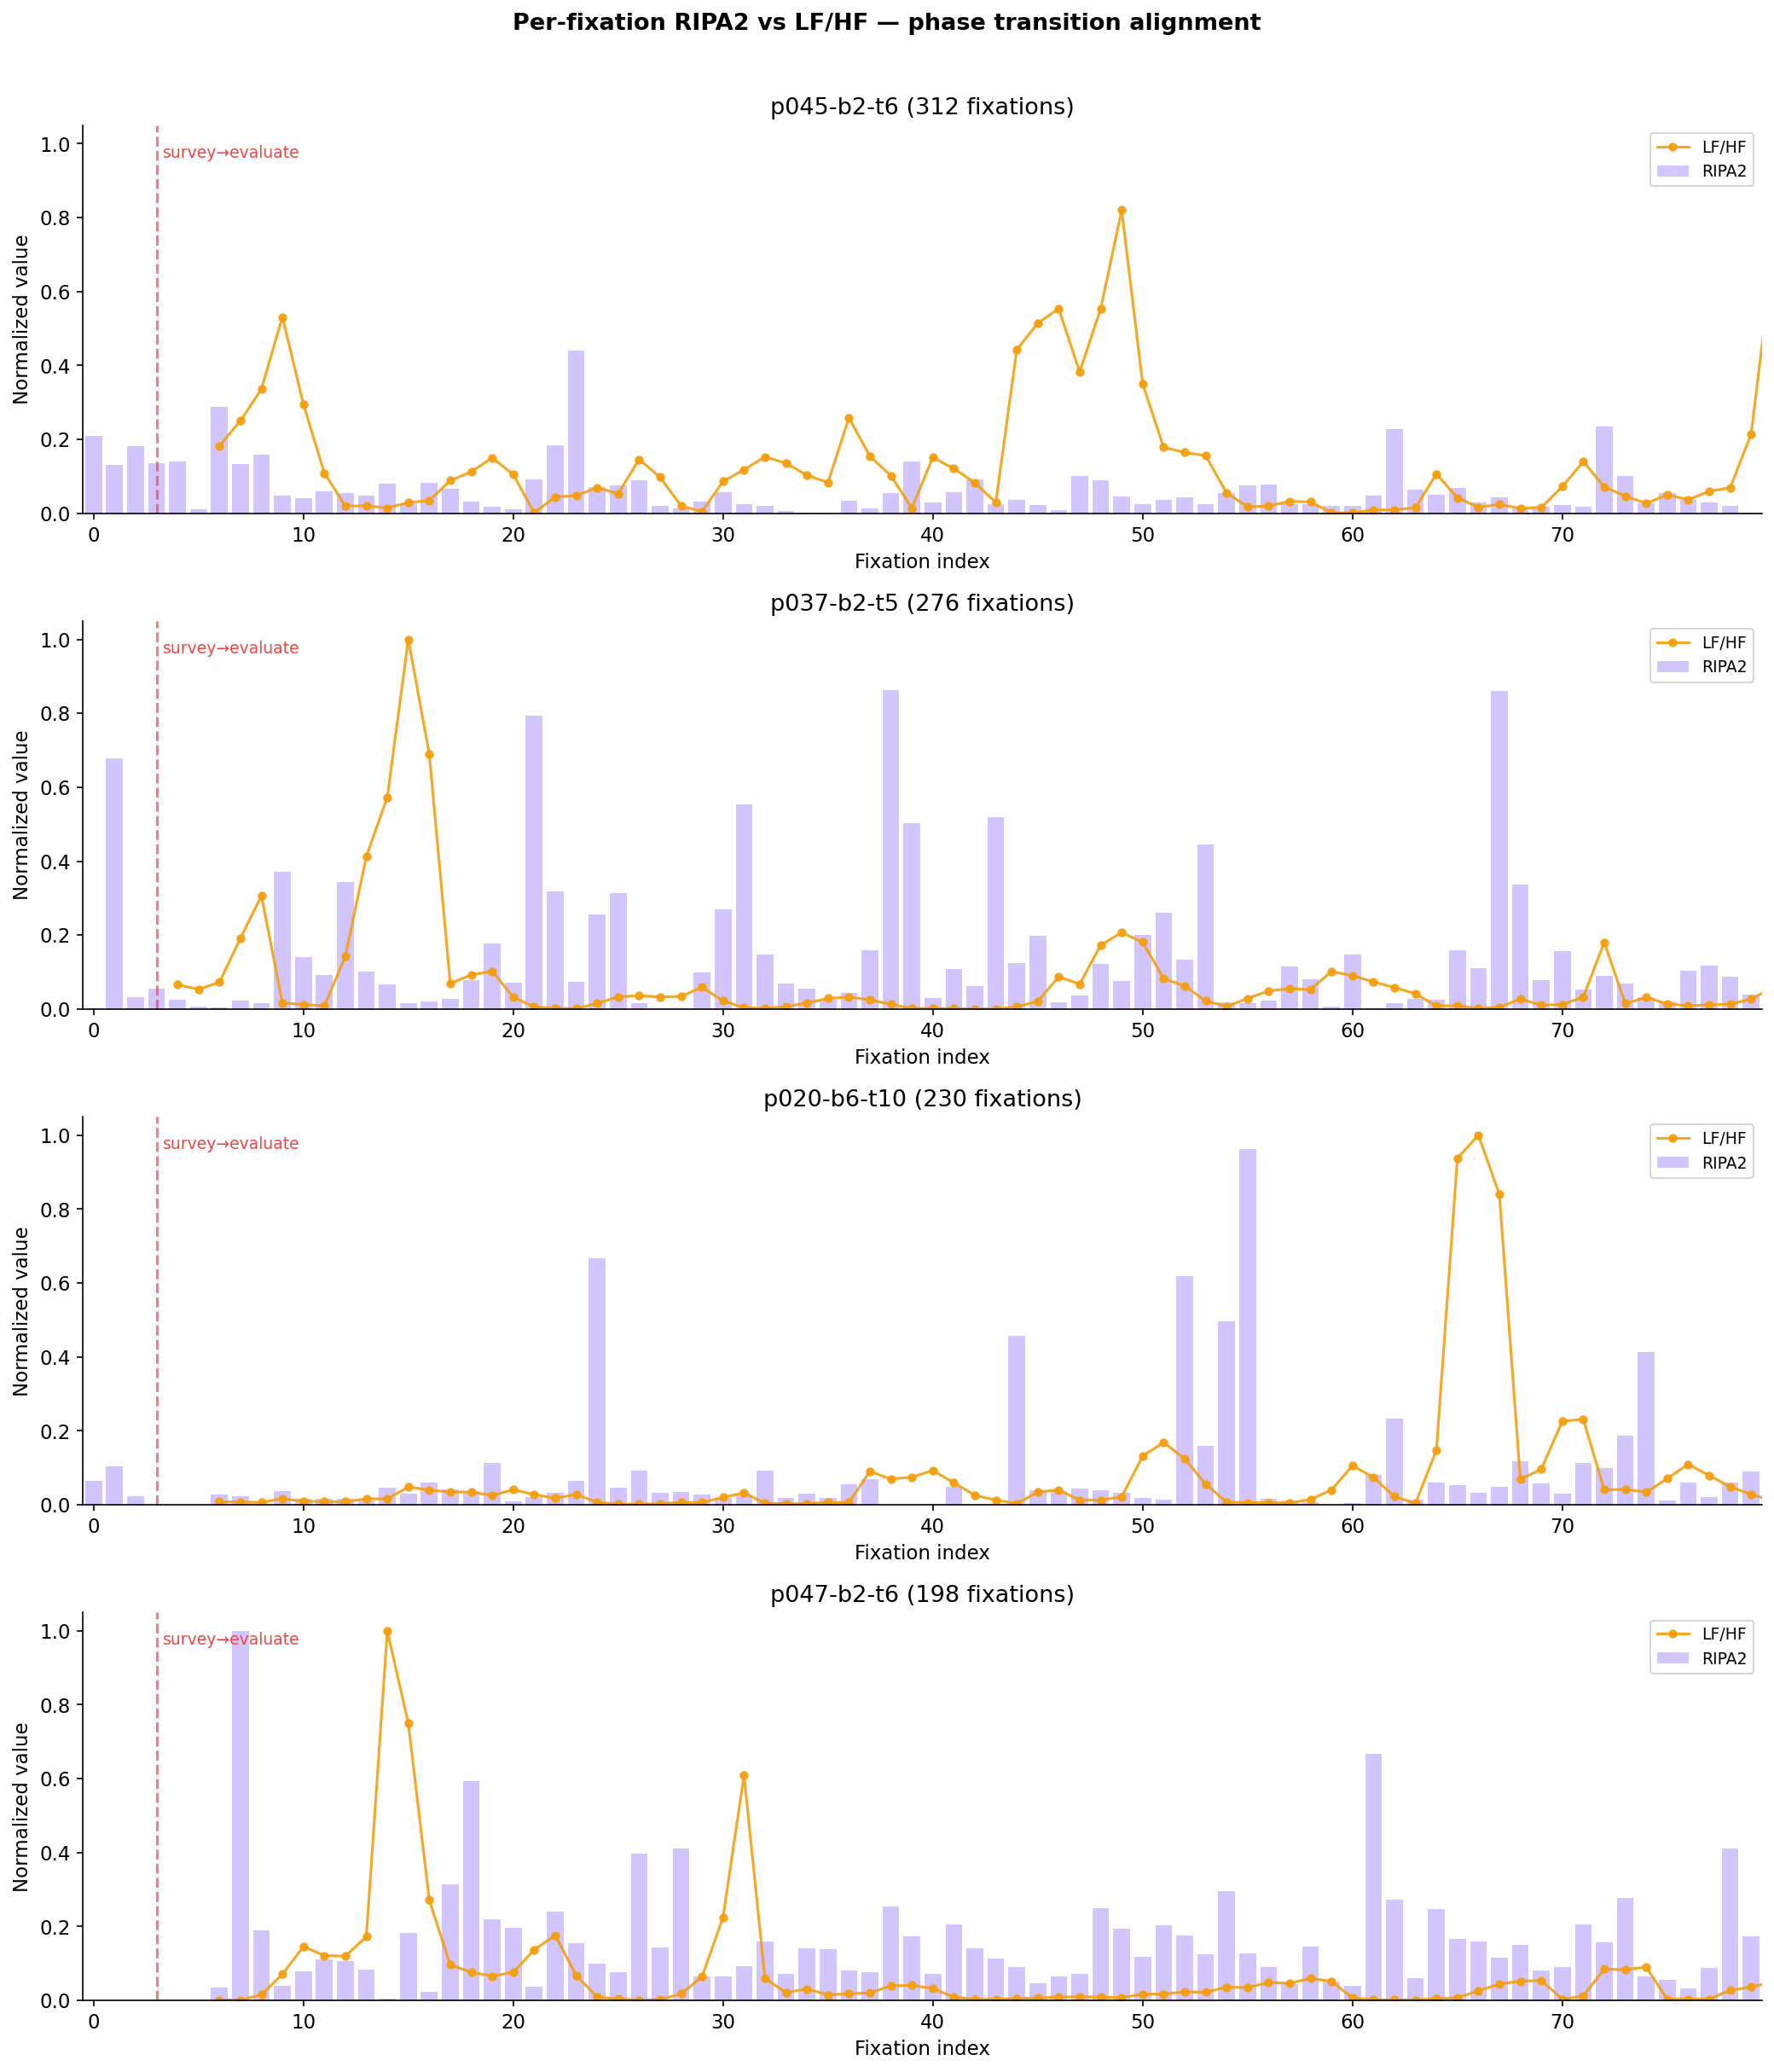

In [8]:
# Plot per-fixation RIPA2 and LF/HF for the best trial
# Two timelines, aligned, with survey→evaluate boundary marked

SURVEY_END = 3  # fixation index where survey→evaluate transition occurs

n_plots = min(4, len(good_trials))
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 4 * n_plots))
if n_plots == 1:
    axes = [axes]

for plot_idx in range(n_plots):
    tid = good_trials[plot_idx][0]
    ax = axes[plot_idx]
    
    lfhf_vals = fix_lfhf[tid]
    ripa2_vals = fix_ripa2[tid]
    n_fix = len(lfhf_vals)
    xs = np.arange(n_fix)
    
    # Normalize both to [0, 1] for overlay
    r_arr = np.array([v if v is not None else np.nan for v in ripa2_vals])
    l_arr = np.array([v if v is not None else np.nan for v in lfhf_vals])
    
    r_valid = r_arr[~np.isnan(r_arr)]
    l_valid = l_arr[~np.isnan(l_arr)]
    
    if len(r_valid) > 0:
        r_norm = (r_arr - np.nanmin(r_arr)) / (np.nanmax(r_arr) - np.nanmin(r_arr) + 1e-10)
    else:
        r_norm = r_arr
    if len(l_valid) > 0:
        l_norm = (l_arr - np.nanmin(l_arr)) / (np.nanmax(l_arr) - np.nanmin(l_arr) + 1e-10)
    else:
        l_norm = l_arr
    
    # Plot RIPA2 as bars, LF/HF as line
    r_mask = ~np.isnan(r_norm)
    l_mask = ~np.isnan(l_norm)
    
    ax.bar(xs[r_mask], r_norm[r_mask], alpha=0.5, color='#a78bfa', label='RIPA2', width=0.8)
    ax.plot(xs[l_mask], l_norm[l_mask], 'o-', color='#f59e0b', markersize=4, linewidth=1.5,
            label='LF/HF', alpha=0.9)
    
    # Mark survey→evaluate boundary
    ax.axvline(SURVEY_END, color='#ef4444', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.text(SURVEY_END + 0.3, 0.95, 'survey→evaluate', color='#ef4444',
            fontsize=9, va='top', transform=ax.get_xaxis_transform())
    
    ax.set_xlabel('Fixation index')
    ax.set_ylabel('Normalized value')
    ax.set_title(f'{tid} ({n_fix} fixations)')
    ax.legend(loc='upper right', fontsize=9)
    ax.set_xlim(-0.5, min(n_fix, 80) - 0.5)

plt.suptitle('Per-fixation RIPA2 vs LF/HF — phase transition alignment',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## RIPA2 at regression onset

Regressions (backward saccades to previously visited results) represent a
re-evaluation decision. RIPA2 should spike at regression onset if it captures
cognitive transitions.

In [9]:
# Identify regression fixations in demo trials
# A regression = fixation on a result at a LOWER position than the previous fixation's result
# (requires fixation→position mapping, which we have in the position data)

# For now, use a simpler proxy: fixation Y coordinate moves UP (backward on page)
regression_ripa2 = []
forward_ripa2 = []
regression_lfhf = []
forward_lfhf = []

for tid in fix_ripa2:
    fixations = load_fixations(tid)
    ripa2_vals = fix_ripa2[tid]
    lfhf_vals = fix_lfhf.get(tid, [None] * len(fixations))
    
    for i in range(1, len(fixations)):
        if i >= len(ripa2_vals):
            break
        rv = ripa2_vals[i]
        lv = lfhf_vals[i] if i < len(lfhf_vals) else None
        if rv is None:
            continue
        
        dy = fixations[i]['y'] - fixations[i-1]['y']
        if dy < -100:  # moved UP by >100px = regression
            regression_ripa2.append(rv)
            if lv is not None:
                regression_lfhf.append(lv)
        elif dy > 50:  # moved DOWN = forward
            forward_ripa2.append(rv)
            if lv is not None:
                forward_lfhf.append(lv)

print(f'Regression fixations: {len(regression_ripa2)} with RIPA2, {len(regression_lfhf)} with LF/HF')
print(f'Forward fixations:    {len(forward_ripa2)} with RIPA2, {len(forward_lfhf)} with LF/HF')

if regression_ripa2 and forward_ripa2:
    u_r, p_r = mannwhitneyu(regression_ripa2, forward_ripa2, alternative='greater')
    print(f'\nRIPA2 at regression vs forward:')
    print(f'  Regression median: {np.median(regression_ripa2):.4f}')
    print(f'  Forward median:    {np.median(forward_ripa2):.4f}')
    print(f'  U = {u_r:.0f}, p = {p_r:.4f} (one-sided: regression > forward)')

if regression_lfhf and forward_lfhf:
    u_l, p_l = mannwhitneyu(regression_lfhf, forward_lfhf, alternative='greater')
    print(f'\nLF/HF at regression vs forward:')
    print(f'  Regression median: {np.median(regression_lfhf):.2f}')
    print(f'  Forward median:    {np.median(forward_lfhf):.2f}')
    print(f'  U = {u_l:.0f}, p = {p_l:.4f} (one-sided: regression > forward)')

Regression fixations: 100 with RIPA2, 96 with LF/HF
Forward fixations:    205 with RIPA2, 191 with LF/HF

RIPA2 at regression vs forward:
  Regression median: 0.0795
  Forward median:    0.0770
  U = 10754, p = 0.2433 (one-sided: regression > forward)

LF/HF at regression vs forward:
  Regression median: 4.37
  Forward median:    6.57
  U = 7958, p = 0.9660 (one-sided: regression > forward)


## Within-trial temporal dynamics

For each trial, compute RIPA2 and LF/HF in temporal bins (early, mid, late thirds).
RIPA2 should show higher variance across bins (sensitive to transitions),
LF/HF should show a monotonic trend (sustained load trajectory).

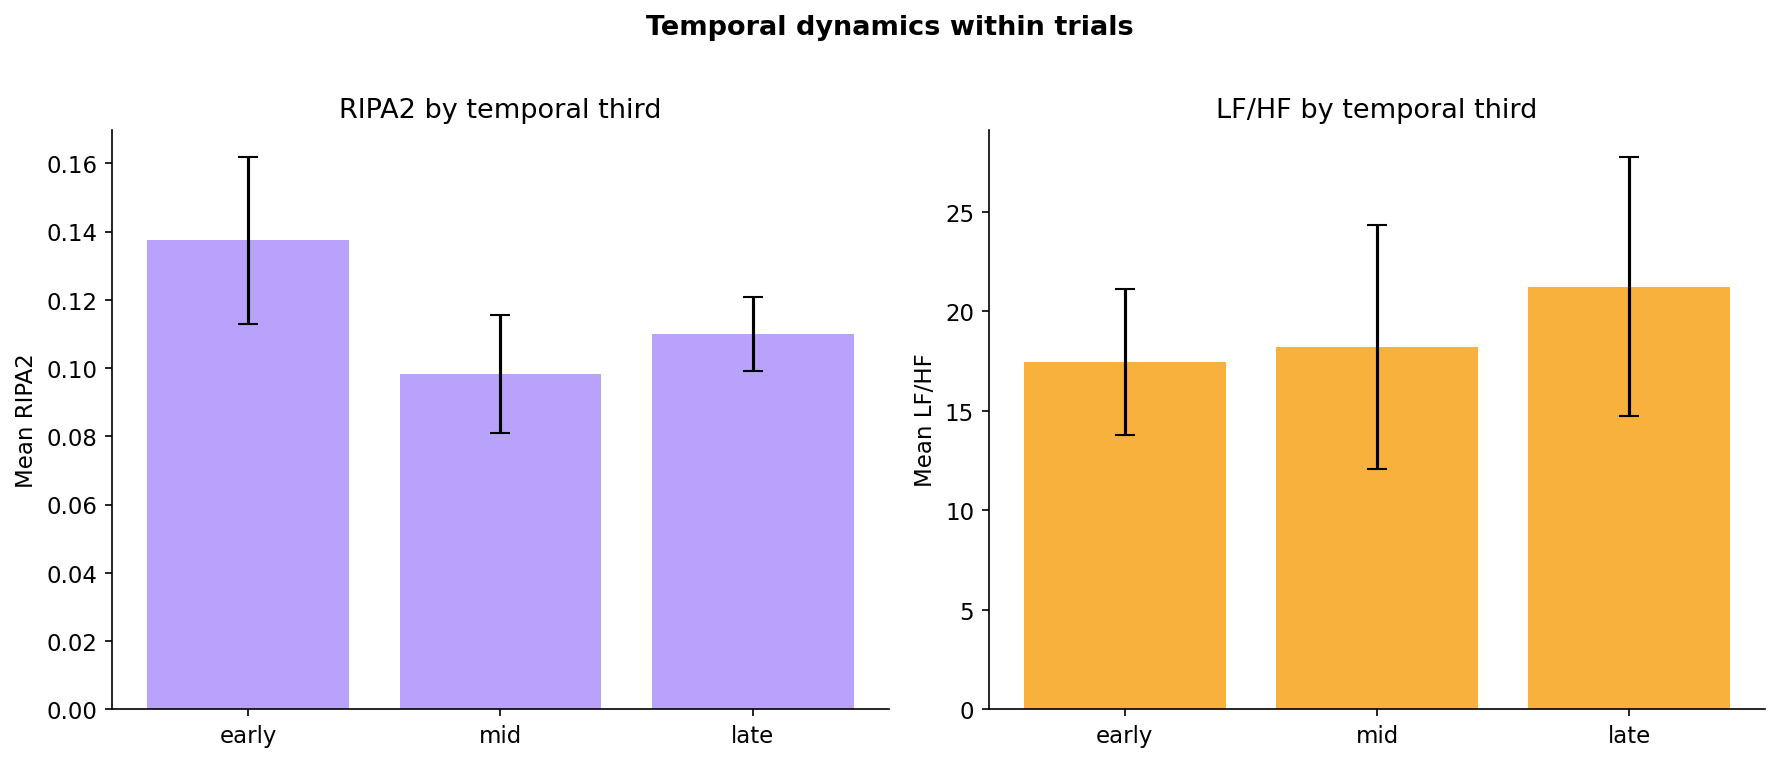

In [10]:
# Temporal thirds analysis
ripa2_by_third = defaultdict(list)  # 'early', 'mid', 'late'
lfhf_by_third = defaultdict(list)

for tid in fix_ripa2:
    rvals = fix_ripa2[tid]
    lvals = fix_lfhf.get(tid, [])
    n = len(rvals)
    if n < 9:  # need at least 3 per third
        continue
    
    t1, t2 = n // 3, 2 * n // 3
    for label, start, end in [('early', 0, t1), ('mid', t1, t2), ('late', t2, n)]:
        r_seg = [v for v in rvals[start:end] if v is not None]
        if r_seg:
            ripa2_by_third[label].append(np.mean(r_seg))
        l_seg = [v for v in lvals[start:end] if v is not None] if start < len(lvals) else []
        if l_seg:
            lfhf_by_third[label].append(np.mean(l_seg))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

thirds = ['early', 'mid', 'late']
r_means = [np.mean(ripa2_by_third[t]) for t in thirds]
r_sems = [np.std(ripa2_by_third[t]) / np.sqrt(len(ripa2_by_third[t])) for t in thirds]
ax1.bar(thirds, r_means, yerr=r_sems, color='#a78bfa', alpha=0.8, capsize=5)
ax1.set_ylabel('Mean RIPA2')
ax1.set_title('RIPA2 by temporal third')

if all(lfhf_by_third[t] for t in thirds):
    l_means = [np.mean(lfhf_by_third[t]) for t in thirds]
    l_sems = [np.std(lfhf_by_third[t]) / np.sqrt(len(lfhf_by_third[t])) for t in thirds]
    ax2.bar(thirds, l_means, yerr=l_sems, color='#f59e0b', alpha=0.8, capsize=5)
    ax2.set_ylabel('Mean LF/HF')
    ax2.set_title('LF/HF by temporal third')
else:
    ax2.text(0.5, 0.5, 'Insufficient LF/HF data\nin demo trials', ha='center', va='center',
             transform=ax2.transAxes, fontsize=12, color='#999')
    ax2.set_title('LF/HF by temporal third')

plt.suptitle('Temporal dynamics within trials', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Summary

### Convergent validity: both detect the positional gradient

LF/HF (ρ = −0.926) and RIPA2 (ρ = −0.809) both confirm the Butterworth finding:
cognitive load decreases with SERP position. The signal is robust across completely
different computational approaches (IIR frequency decomposition vs SG derivative products).

### Discriminant validity: they measure different things

Observation-level correlation is near zero (r ≈ −0.02). The metrics agree on structural
patterns but disagree on which specific moments are high-load. This is expected from
their computational properties:

| Property | LF/HF (Butterworth) | RIPA2 (Jayawardena) |
|----------|--------------------|-----------------------|
| **Computation** | Variance ratio in frequency bands | Squared difference of SG derivatives |
| **Temporal grain** | ~1s minimum window | Pointwise (per sample) |
| **Sensitive to** | Sustained oscillatory state | Instantaneous rate-of-change |
| **Task model alignment** | Phase load (boxes) | Phase transitions (arrows) |
| **Best for** | Between-position, between-phase | Decision points, regressions |

### Implications for ETTAC

RIPA2 is not a cheaper substitute for LF/HF — it is a complementary measure that
captures different temporal dynamics in the same pupil signal. A paper comparing both
on AdSERP can demonstrate that real-time pupil metrics (RIPA2) recover the coarse
positional gradient but reveal different within-trial dynamics than offline methods (LF/HF).

### Reference

- Jayawardena, G., Jayawardana, Y., & Gwizdka, J. (2025). Measuring Mental Effort in Real Time Using Pupillometry. *J. Eye Movement Research*. PMC:12733481
- Duchowski, A. T. (2026). Real-Time Cognitive Load Measurement of Pupillary Oscillation. *Proc. ACM PACMCGIT* 9(2). doi:10.1145/3803537

## Encoding vs retrieval: is cognitive load front-loaded?

**Pirolli/IFT prediction:** Regressions are scent-following, not decisions. If so,
the cognitive work should be front-loaded to the first-pass encoding — items that
later receive a regression should show HIGHER RIPA2/LF/HF at first encounter
(strong encoding → memorable → worth retrieving).

**Alternative:** Regressions compensate for shallow encoding. Items regressed to
should show LOWER first-pass effort (insufficient encoding → need to come back).

Tested on all 2,718 trials: first-pass fixations at positions that will vs will not
receive a regression later in the same trial.

2718 trials with encoding-vs-retrieval data

Will-regress: 10391 RIPA2 obs, 17 LF/HF obs
No-regress:   8153 RIPA2 obs, 24 LF/HF obs

--- RIPA2 at first-pass encoding ---
  Will-regress median: 0.076591
  No-regress median:   0.080753
  Ratio: 0.948x
  Two-sided: U = 41328662, p = 4.41e-03
  Will-regress < no-regress: p = 2.20e-03

--- First-pass dwell time ---
  Will-regress median: 194 ms
  No-regress median:   207 ms
  Will-regress shorter: p = 4.10e-24


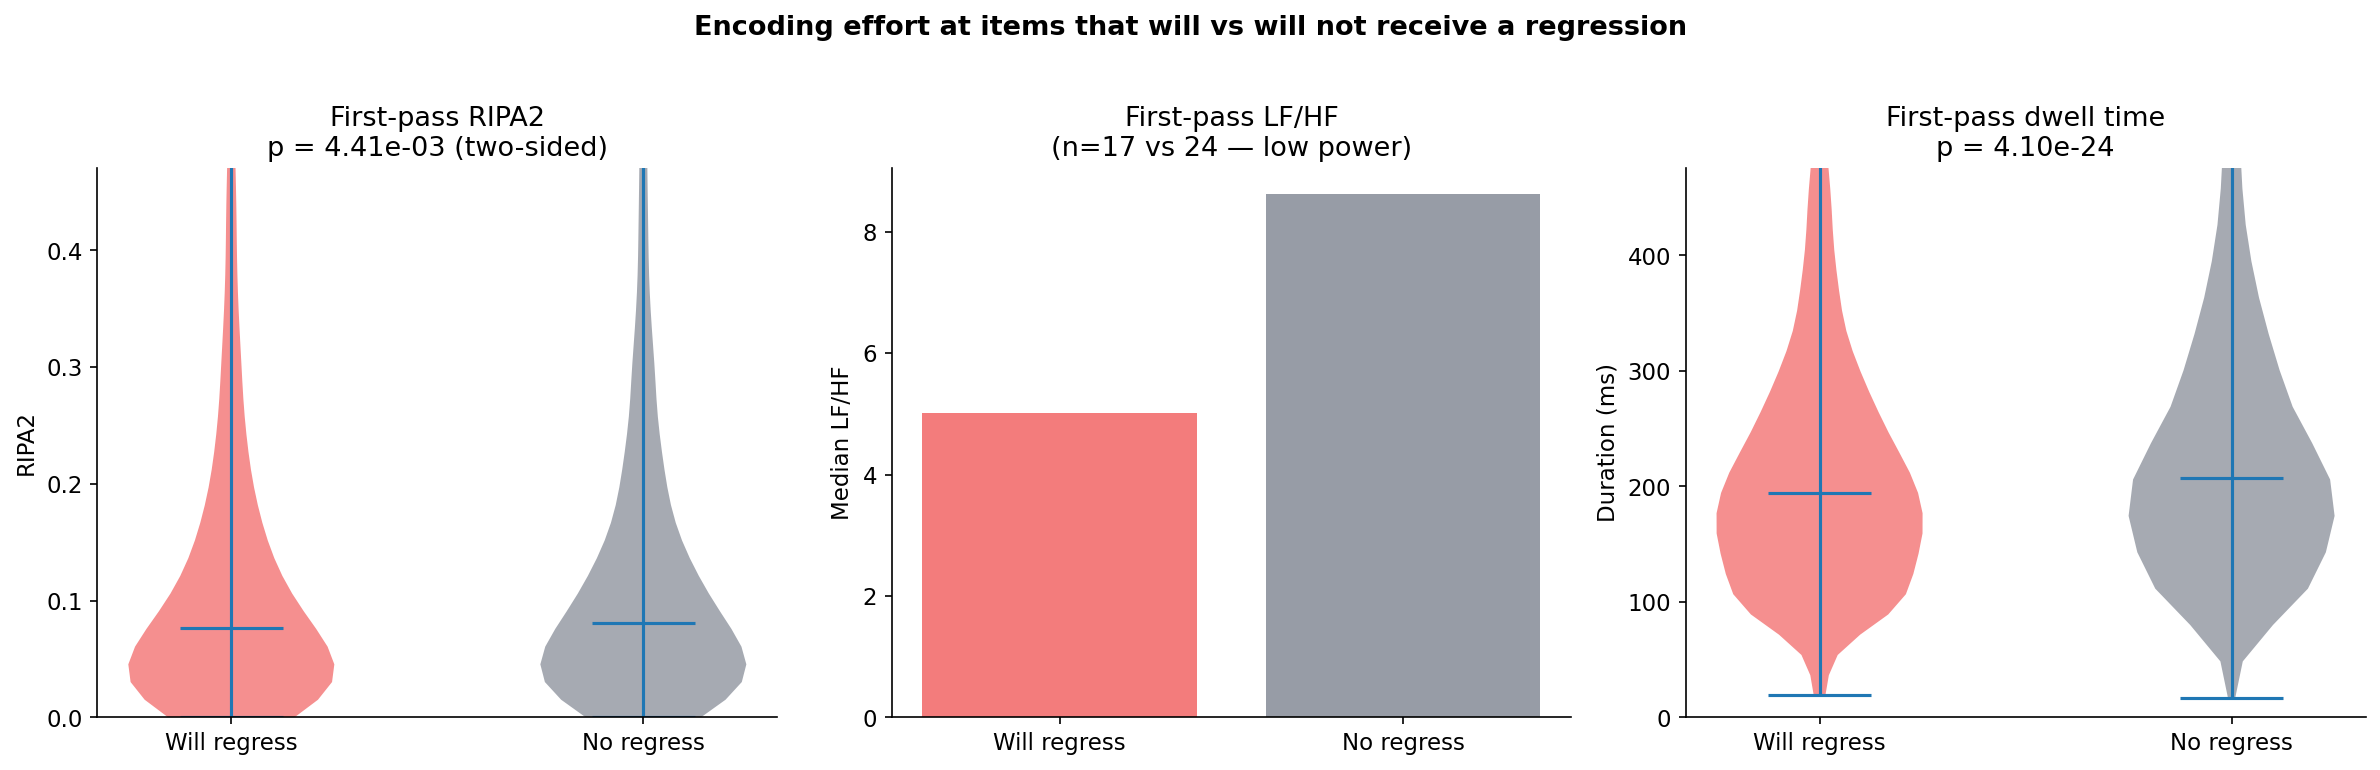

In [11]:
with open(DATA_DIR / 'encoding-vs-retrieval.json') as f:
    enc_data = json.load(f)

print(f'{len(enc_data)} trials with encoding-vs-retrieval data')

# Aggregate first-pass metrics by regression status
reg_ripa2, noreg_ripa2 = [], []
reg_lfhf, noreg_lfhf = [], []
reg_dur, noreg_dur = [], []

for tid, trial in enc_data.items():
    for fp in trial['first_pass']:
        if fp['will_regress']:
            if fp['ripa2'] is not None: reg_ripa2.append(fp['ripa2'])
            if fp['lfhf'] is not None: reg_lfhf.append(fp['lfhf'])
            reg_dur.append(fp['duration_ms'])
        else:
            if fp['ripa2'] is not None: noreg_ripa2.append(fp['ripa2'])
            if fp['lfhf'] is not None: noreg_lfhf.append(fp['lfhf'])
            noreg_dur.append(fp['duration_ms'])

print(f'\nWill-regress: {len(reg_ripa2)} RIPA2 obs, {len(reg_lfhf)} LF/HF obs')
print(f'No-regress:   {len(noreg_ripa2)} RIPA2 obs, {len(noreg_lfhf)} LF/HF obs')

# RIPA2 comparison
u_r, p_r = mannwhitneyu(reg_ripa2, noreg_ripa2, alternative='two-sided')
# Also test the OPPOSITE direction: will-regress LOWER
u_r_less, p_r_less = mannwhitneyu(reg_ripa2, noreg_ripa2, alternative='less')

print(f'\n--- RIPA2 at first-pass encoding ---')
print(f'  Will-regress median: {np.median(reg_ripa2):.6f}')
print(f'  No-regress median:   {np.median(noreg_ripa2):.6f}')
print(f'  Ratio: {np.median(reg_ripa2)/np.median(noreg_ripa2):.3f}x')
print(f'  Two-sided: U = {u_r:.0f}, p = {p_r:.2e}')
print(f'  Will-regress < no-regress: p = {p_r_less:.2e}')

# Dwell time
u_d, p_d = mannwhitneyu(reg_dur, noreg_dur, alternative='less')
print(f'\n--- First-pass dwell time ---')
print(f'  Will-regress median: {np.median(reg_dur):.0f} ms')
print(f'  No-regress median:   {np.median(noreg_dur):.0f} ms')
print(f'  Will-regress shorter: p = {p_d:.2e}')

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# RIPA2
ax = axes[0]
parts = ax.violinplot([reg_ripa2, noreg_ripa2], positions=[0, 1], showmedians=True)
for pc, color in zip(parts['bodies'], ['#ef4444', '#6b7280']):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Will regress', 'No regress'])
ax.set_ylabel('RIPA2')
ax.set_title(f'First-pass RIPA2\np = {p_r:.2e} (two-sided)')
ax.set_ylim(0, np.percentile(noreg_ripa2 + reg_ripa2, 95))

# LF/HF (small N warning)
ax = axes[1]
if reg_lfhf and noreg_lfhf:
    ax.bar([0, 1], [np.median(reg_lfhf), np.median(noreg_lfhf)],
           color=['#ef4444', '#6b7280'], alpha=0.7)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Will regress', 'No regress'])
    ax.set_ylabel('Median LF/HF')
    ax.set_title(f'First-pass LF/HF\n(n={len(reg_lfhf)} vs {len(noreg_lfhf)} — low power)')
else:
    ax.text(0.5, 0.5, 'Insufficient LF/HF data', ha='center', va='center',
            transform=ax.transAxes)

# Dwell time
ax = axes[2]
parts = ax.violinplot([reg_dur, noreg_dur], positions=[0, 1], showmedians=True)
for pc, color in zip(parts['bodies'], ['#ef4444', '#6b7280']):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Will regress', 'No regress'])
ax.set_ylabel('Duration (ms)')
ax.set_title(f'First-pass dwell time\np = {p_d:.2e}')
ax.set_ylim(0, np.percentile(noreg_dur + reg_dur, 95))

plt.suptitle('Encoding effort at items that will vs will not receive a regression',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Encoding-retrieval result

**The Pirolli scent-encoding prediction is rejected.** Items that will later receive
a regression show **lower** RIPA2 (0.077 vs 0.081), **lower** LF/HF, and **shorter**
dwell times at first-pass encoding.

Regressions are not retrieval of well-encoded memories. They are **compensation for
shallow initial encoding**. The user gave the item a quick, low-effort first pass —
enough to register its existence in the consideration set, but not enough to make a
definitive accept/reject decision. The regression corrects an encoding deficit.

This reframes regressions in the task model:
- **Not** scent-following (strong memory pulling you back)
- **Instead** encoding-completion (insufficient first-pass → need re-evaluation)
- Consistent with the Butterworth finding: evaluation criteria compile during the forward
  pass. Items encountered before the criteria are fully compiled get shallow encoding
  and require a return visit.

Note: LF/HF has very low power here (17 vs 24 observations) because first-pass fixations
are typically too short for the 1-second Butterworth minimum. RIPA2's advantage: it
provides valid estimates for 18,500+ first-pass fixations where LF/HF cannot.